# Conditions side by side

All six run conditions, pooled over datasets (8 datasets × 3 trials per box).

* **Outcome** — share of a trial's Statistics + Decoder metrics passed.
* **Process** — share of a trial's questions both supervised judges rated ≥ ok.

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd

%load_ext autoreload
%autoreload 2

import seaborn as sns

# The house style, same as the two notebooks this one pools.
sns.set_theme(style="ticks", rc={"axes.spines.right": False,
                                "axes.spines.top": False})
mpl.rcParams["figure.dpi"] = 100
mpl.rcParams["savefig.dpi"] = 300
mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42
from ratings import (add_combined, conditions, drop_efficiency,
                     load_condition_ratings)
from ratings.experiments import CONDITION_LABEL, CONDITION_ORDER
import outcome_analysis as ot

Under each box: mean ± SE.

Brackets: paired permutation test within dataset (raw p). The statistic is each dataset's
mean gap between the two conditions, averaged over datasets; the null shuffles the two
conditions' trials within each dataset. Dataset difficulty therefore cancels out, and the
box widths (which are mostly between-dataset spread) say little about the p value.
`k/n` before p: the datasets, of the n both conditions cover, on which the right-hand box
scored higher (ties count for neither).

/tmp/ipykernel_156577/3184112451.py:2: UserWarning: zhang2025: judge files map different numbers of questions depending on the condition (29-30): {'claude-code/full': array([30]), 'claude-code/minimal': array([30, 29]), 'codex/full': array([30]), 'codex/minimal': array([30]), 'terminus-gpt/full': array([30]), 'terminus-opus/full': array([30])}. Arm comparisons for this dataset are not like-for-like.
  add_combined(drop_efficiency(load_condition_ratings().tidy)), rater="combined")


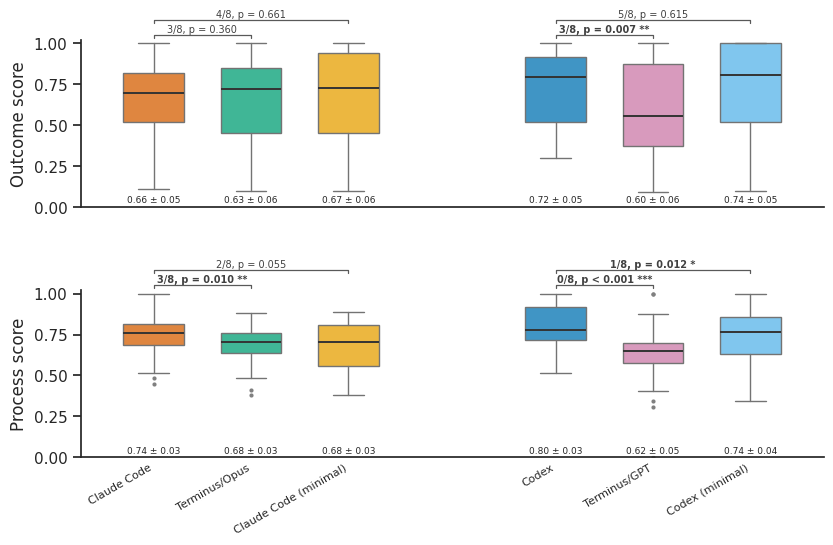

In [2]:
process = conditions.condition_scores(
    add_combined(drop_efficiency(load_condition_ratings().tidy)), rater="combined")

outcome = ot.trial_scores(ot.load(arms=ot.ALL_ARMS))
outcome = outcome[outcome.category == "Outcome"]

# Within each family: the harness swap, then the prompt cut.
TESTS = [("claude-code/full", "terminus-opus/full"),
         ("claude-code/full", "claude-code/minimal"),
         ("codex/full", "terminus-gpt/full"),
         ("codex/full", "codex/minimal")]

fig, _ = conditions.condition_boxes(
    [("Outcome score", outcome, "score"),
     ("Process score", process, "frac_ok")],
    tests=TESTS, figsize=(8.4, 6))

# fig.savefig('./compare_agents.pdf', bbox_inches='tight', dpi=300)
plt.show()

## Prompt engineering: the v5 prompt

Same agents (Opus 4.6 / GPT-5.4) on the revised full prompt. v5 was only run on the
5 datasets whose prompts changed, so every box here is restricted to those 5.

/tmp/ipykernel_156577/3495725378.py:5: UserWarning: zhang2025: judge files map different numbers of questions depending on the condition (29-30): {'claude-code/full': array([30]), 'claude-code/minimal': array([30, 29]), 'codex/full': array([30]), 'codex/minimal': array([30]), 'terminus-gpt/full': array([30]), 'terminus-opus/full': array([30])}. Arm comparisons for this dataset are not like-for-like.
  add_combined(drop_efficiency(load_condition_ratings(conditions=V5_ARMS).tidy)),


['chen2024', 'hasnain2024', 'majnik2025', 'sosa2024', 'zhong2025']


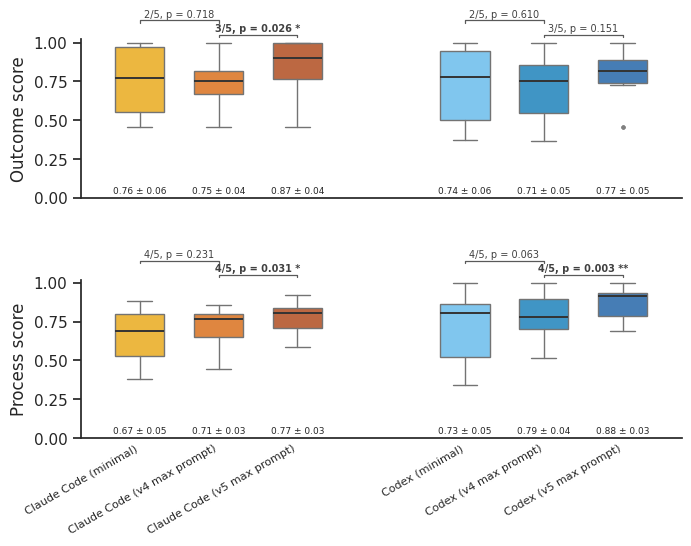

In [3]:
from ratings import experiments

V5_ARMS = ot.ALL_ARMS + experiments.V5_CONDITIONS
process_v5 = conditions.condition_scores(
    add_combined(drop_efficiency(load_condition_ratings(conditions=V5_ARMS).tidy)),
    rater="combined")
outcome_v5 = ot.trial_scores(ot.load(arms=V5_ARMS), arms=V5_ARMS)
outcome_v5 = outcome_v5[outcome_v5.category == "Outcome"]

# only the datasets the v5 prompt was run on
V5 = {a: f"{a}{experiments.PROMPT_V5}/full" for a in ("claude-code", "codex")}
DS5 = set(process_v5[process_v5.condition.isin(V5.values())].dataset)
process_v5, outcome_v5 = (s[s.dataset.isin(DS5)] for s in (process_v5, outcome_v5))

GROUPS = [(f"{a}/minimal", f"{a}/full", V5[a]) for a in V5]
TESTS_V5 = [(f"{a}/full", V5[a]) for a in V5] + [(f"{a}/full", f"{a}/minimal") for a in V5]
LABELS_V5 = {c: experiments.CONDITION_SHORT[c] for g in GROUPS for c in g}
LABELS_V5.update({f"{a}/full": f"{experiments.AGENT_LABEL[a]} (v4 max prompt)" for a in V5})

fig, _ = conditions.condition_boxes(
    [("Outcome score", outcome_v5, "score"),
     ("Process score", process_v5, "frac_ok")],
    groups=GROUPS, tests=TESTS_V5, labels=LABELS_V5, figsize=(7, 6))
print(sorted(DS5))
plt.show()

## Effect of Prompt and Model

Per harness, three steps: original (old model, v4 prompt) → old model, v5 prompt →
new model (Opus 5 / GPT-5.6), v5 prompt. Max prompt throughout, same (old) judges,
restricted to the 5 datasets with v5 runs. Brackets: every pair.

['chen2024', 'hasnain2024', 'majnik2025', 'sosa2024', 'zhong2025']


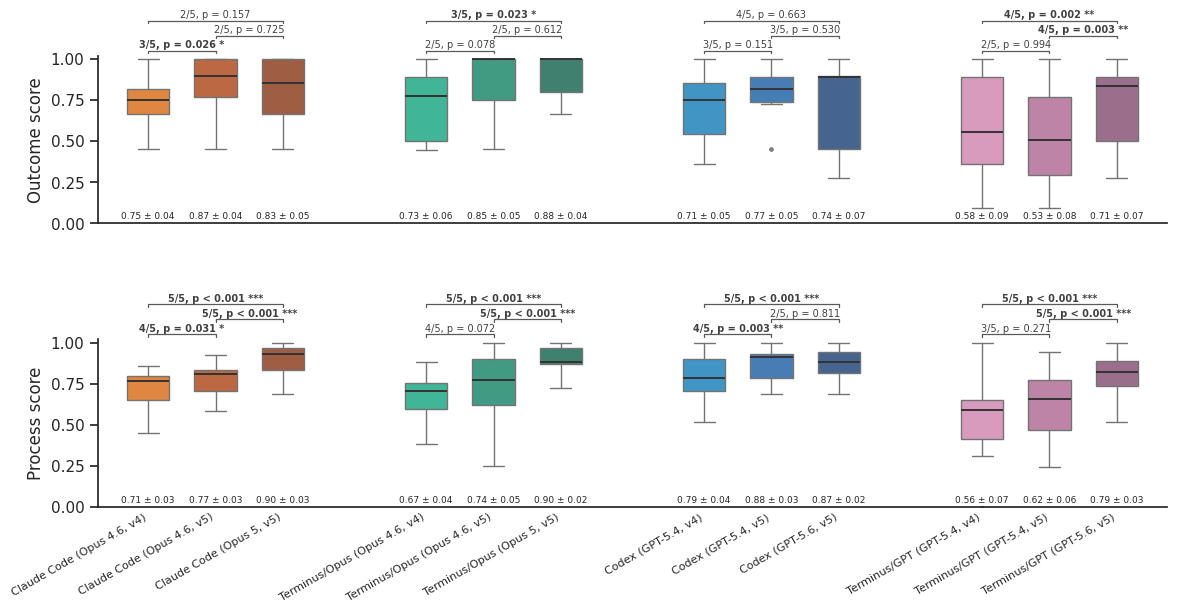

In [4]:
from ratings.analysis.loading import DATASET_ORDER

HARNESSES = ("claude-code", "terminus-opus", "codex", "terminus-gpt")
ORIG = {a: f"{a}/full" for a in HARNESSES}
V5_OLD = {a: f"{a}{experiments.PROMPT_V5}/full" for a in HARNESSES}
NEW = {a: f"{a}{experiments.NEW_MODELS}/full" for a in HARNESSES}
STEP_ARMS = (tuple((a, "full") for a in HARNESSES)
             + experiments.V5_CONDITIONS + experiments.NEW_MODEL_CONDITIONS)

# the 8 datasets only -- the tree also holds the <task>_api variants
process_steps = conditions.condition_scores(
    add_combined(drop_efficiency(load_condition_ratings(
        datasets=DATASET_ORDER, conditions=STEP_ARMS).tidy)),
    rater="combined")
outcome_steps = ot.trial_scores(ot.load(arms=STEP_ARMS), arms=STEP_ARMS)
outcome_steps = outcome_steps[outcome_steps.category == "Outcome"]

# only the datasets the old models were re-run on with the v5 prompt
DS5 = set(process_steps[process_steps.condition.isin(V5_OLD.values())].dataset)
process_steps, outcome_steps = (s[s.dataset.isin(DS5)]
                                for s in (process_steps, outcome_steps))

GROUPS_STEPS = [(ORIG[a], V5_OLD[a], NEW[a]) for a in HARNESSES]
TESTS_STEPS = [pair for o, v, n in GROUPS_STEPS for pair in ((o, v), (v, n), (o, n))]
old, new = zip(*(experiments.MODEL_NAME[a] for a in HARNESSES))
LABELS_STEPS = {}
for a, m_old, m_new in zip(HARNESSES, old, new):
    name = experiments.AGENT_LABEL[a]
    LABELS_STEPS.update({ORIG[a]: f"{name} ({m_old}, v4)",
                         V5_OLD[a]: f"{name} ({m_old}, v5)",
                         NEW[a]: f"{name} ({m_new}, v5)"})

fig, _ = conditions.condition_boxes(
    [("Outcome score", outcome_steps, "score"),
     ("Process score", process_steps, "frac_ok")],
    groups=GROUPS_STEPS, tests=TESTS_STEPS, labels=LABELS_STEPS, figsize=(12, 7))
print(sorted(DS5))
plt.show()

## Combined analysis

Each family left to right: old model on the min prompt → v4 max prompt (the paper) →
v5 max prompt → new model (v5) → new model in the Terminus harness (v5). All 8 datasets;
for Allen2P, Lee2025 and Zhang2025, whose prompts changed only in shared wording, the v4
runs stand in for old model + v5. Brackets: neighboring steps.

/tmp/ipykernel_156577/3664555135.py:7: UserWarning: zhang2025: judge files map different numbers of questions depending on the condition (29-30): {'claude-code-config_20260919/full': array([30]), 'claude-code/full': array([30]), 'claude-code/minimal': array([30, 29]), 'codex-config_20260919/full': array([30]), 'codex/full': array([30]), 'codex/minimal': array([30]), 'terminus-gpt-config_20260919/full': array([30]), 'terminus-opus-config_20260919/full': array([30])}. Arm comparisons for this dataset are not like-for-like.
  add_combined(drop_efficiency(load_condition_ratings(


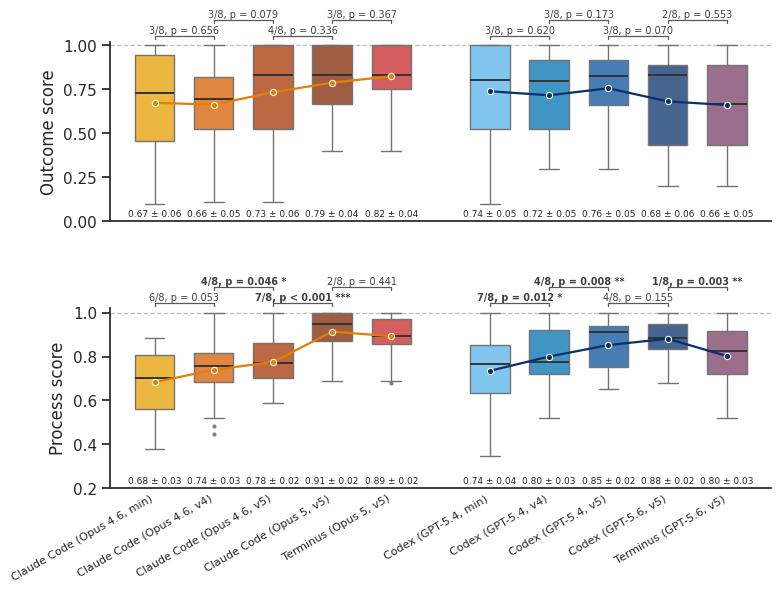

In [ ]:
NEW_TERMINUS = {"claude-code": "terminus-opus", "codex": "terminus-gpt"}
FAMILY_STEPS = {a: (f"{a}/minimal", f"{a}/full", V5_OLD[a], NEW[a], NEW[t])
                for a, t in NEW_TERMINUS.items()}
ALL_STEP_ARMS = tuple(tuple(c.split("/")) for steps in FAMILY_STEPS.values() for c in steps)

process_all = conditions.condition_scores(
    add_combined(drop_efficiency(load_condition_ratings(
        datasets=DATASET_ORDER, conditions=ALL_STEP_ARMS).tidy)),
    rater="combined")
outcome_all = ot.trial_scores(ot.load(arms=ALL_STEP_ARMS), arms=ALL_STEP_ARMS)
outcome_all = outcome_all[outcome_all.category == "Outcome"]

# v4 trials stand in for old model + v5 where the v5 prompt was not re-run
for a in FAMILY_STEPS:
    process_all = conditions.stand_in(process_all, V5_OLD[a], f"{a}/full")
    outcome_all = conditions.stand_in(outcome_all, V5_OLD[a], f"{a}/full")

TESTS_ALL = [pair for steps in FAMILY_STEPS.values() for pair in zip(steps, steps[1:])]
LABELS_ALL = {}
for a, t in NEW_TERMINUS.items():
    m_old, m_new = experiments.MODEL_NAME[a]
    name = experiments.AGENT_LABEL[a]
    LABELS_ALL.update({f"{a}/minimal": f"{name} ({m_old}, min)",
                       f"{a}/full": f"{name} ({m_old}, v4)",
                       V5_OLD[a]: f"{name} ({m_old}, v5)",
                       NEW[a]: f"{name} ({m_new}, v5)",
                       NEW[t]: f"Terminus ({m_new}, v5)"})

# Terminus + Opus 5 in red, so the Claude side runs orange -> red;
# a line joins each condition's mean score, orange for Claude and navy for Codex;
# dashed gray at 1.0 marks the ceiling
fig, _ = conditions.condition_boxes(
    [("Outcome score", outcome_all, "score"),
     ("Process score", process_all, "frac_ok", (0.2, 1.02))],
    groups=list(FAMILY_STEPS.values()), tests=TESTS_ALL, labels=LABELS_ALL,
    width=0.3, spacing=0.45, gap=0.3, figsize=(8, 6.5),
    colors={NEW["terminus-opus"]: "#C62828"}, connect=True,
    connect_color=["#E67E00", "#08306B"], ceiling=1.0)
# fig.savefig('./compare_all.pdf', bbox_inches='tight', dpi=300)
plt.show()

## Forcing the API

Claude Code (Opus 5) and Codex (GPT-5.6), v5 max prompt, with and without the order to
read the data through the format's own library (pynwb, allensdk, ONE). Only the 4
datasets with an API variant: Allen2P, Chen2024, Sosa2024, Zhang2025.

['allen2p', 'chen2024', 'sosa2024', 'zhang2025']


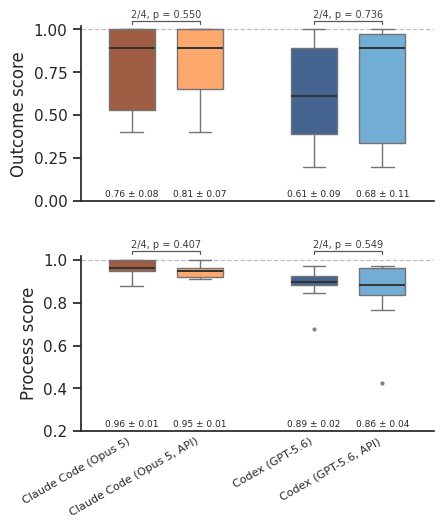

In [ ]:
API_AGENTS = ("claude-code", "codex")
API = {a: f"{a}{experiments.NEW_MODELS}/api" for a in API_AGENTS}
API_ARMS = tuple((a + experiments.NEW_MODELS, p) for a in API_AGENTS for p in ("full", "api"))

process_api = conditions.condition_scores(
    add_combined(drop_efficiency(load_condition_ratings(
        datasets=DATASET_ORDER, conditions=API_ARMS).tidy)),
    rater="combined")
outcome_api = ot.trial_scores(ot.load(arms=API_ARMS), arms=API_ARMS)
outcome_api = outcome_api[outcome_api.category == "Outcome"]

# only the datasets with an API variant
DS_API = set(process_api[process_api.condition.isin(API.values())].dataset)
process_api, outcome_api = (s[s.dataset.isin(DS_API)] for s in (process_api, outcome_api))

GROUPS_API = [(NEW[a], API[a]) for a in API_AGENTS]
LABELS_API = {c: experiments.CONDITION_SHORT[c] for g in GROUPS_API for c in g}

fig, _ = conditions.condition_boxes(
    [("Outcome score", outcome_api, "score"),
     ("Process score", process_api, "frac_ok", (0.2, 1.02))],
    groups=GROUPS_API, tests=GROUPS_API, labels=LABELS_API,
    width=0.3, spacing=0.45, gap=0.3, figsize=(4.5, 5.6), ceiling=1.0)
print(sorted(DS_API))
# fig.savefig('./compare_api.pdf', bbox_inches='tight', dpi=300)
plt.show()